<a href="https://colab.research.google.com/github/Praj24-04/Machine-Learning/blob/main/MLPrac13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTING LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# **LOAD DATASET**

In [ ]:
df = pd.read_csv("Iris.csv")

print(df.head())
print(df.columns)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


# **DATA PRE-PROCESSING**

In [ ]:
df = df.drop('Id', axis=1)
X = df.iloc[:, :-1]   # all features except species

In [ ]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

X = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]

print("After removing outliers:", X.shape)

After removing outliers: (146, 4)


# **FEATURE SCALING**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **ELBOW METHOD**

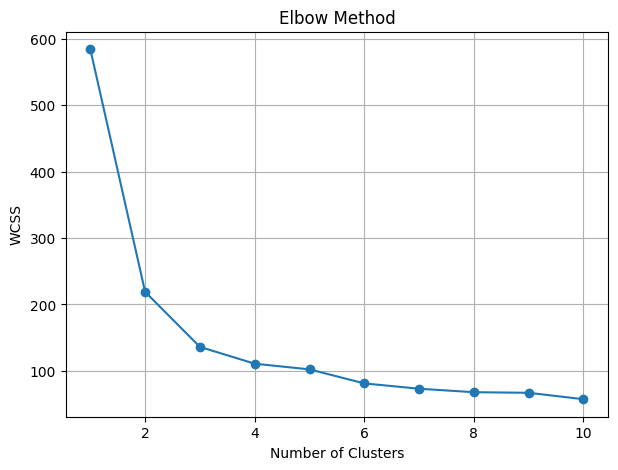

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

# **APPLY K-MEANS CLUSTERING TAKE 4 AND 5 CLUSTERS**

In [ ]:
kmeans1 = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [ ]:
kmeans2 = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# **VISUALIZATION**

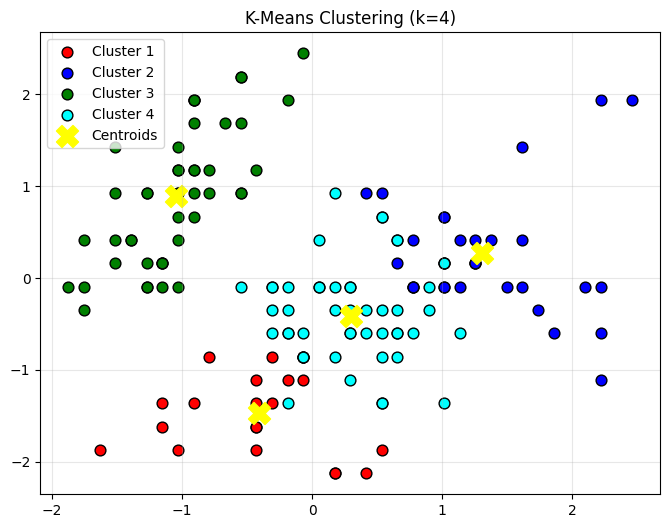

In [ ]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)
y_kmeans_4 = kmeans_4.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'cyan']

for i in range(4):
    plt.scatter(
        X_scaled[y_kmeans_4 == i, 0],
        X_scaled[y_kmeans_4 == i, 1],
        color=colors[i],
        s=60,
        edgecolor='black',
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans_4.cluster_centers_[:, 0],
    kmeans_4.cluster_centers_[:, 1],
    color='yellow',
    s=250,
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering (k=4)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

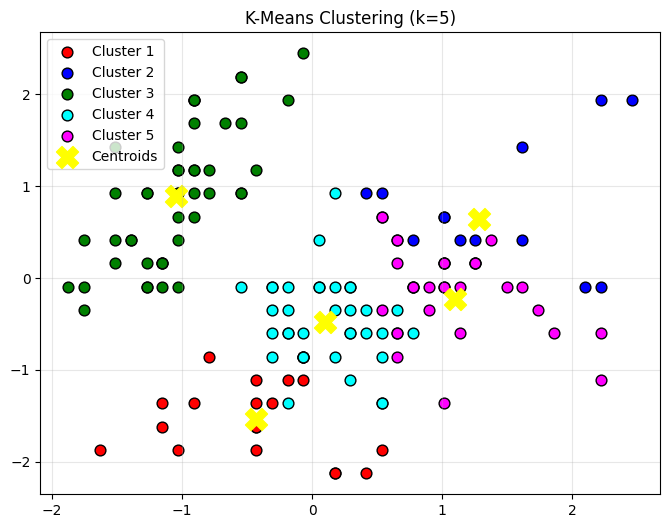

In [ ]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
y_kmeans_5 = kmeans_5.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(
        X_scaled[y_kmeans_5 == i, 0],
        X_scaled[y_kmeans_5 == i, 1],
        color=colors[i],
        s=60,
        edgecolor='black',
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans_5.cluster_centers_[:, 0],
    kmeans_5.cluster_centers_[:, 1],
    color='yellow',
    s=250,
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

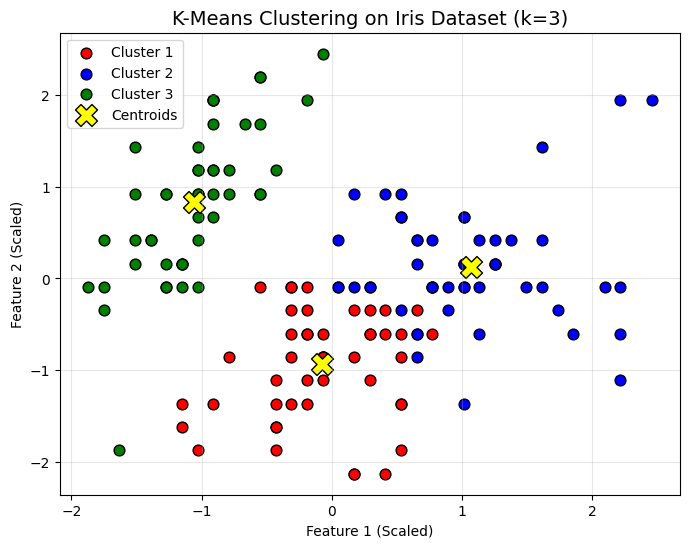

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for i in range(3):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        color=colors[i],
        s=60,
        edgecolor='black',
        label=f'Cluster {i+1}'
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='yellow',
    s=250,
    marker='X',
    edgecolor='black',
    label='Centroids'
)

# Labels and title
plt.title('K-Means Clustering on Iris Dataset (k=3)', fontsize=14)
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **MODEL EVALUATION USING SILHOUETTE SCORE**

In [ ]:
from sklearn.metrics import silhouette_score

score_3 = silhouette_score(X_scaled, y_kmeans)
score_4 = silhouette_score(X_scaled, y_kmeans_4)
score_5 = silhouette_score(X_scaled, y_kmeans_5)

print("Silhouette Score (k=4):", score_4)
print("Silhouette Score (k=5):", score_5)
print("Silhouette Score (k=3):", score_3)

Silhouette Score (k=4): 0.4147413662578325
Silhouette Score (k=5): 0.36792564768996744
Silhouette Score (k=3): 0.45736293607015804
